## MamaDey AI - NDHS 2018 Data Loading, Cleaning & EDA
**Dissertation:** MamaDey AI; AI-Enabled Maternal Risk Prediction Framework, Ogun State Nigeria  
**Author:** Kanyisola Fagbayi  
**Dataset:** Nigeria Demographic and Health Survey (NDHS) 2018 - Individual Recode (NGIR7BFL)  
**Goal:** Load, filter, clean and explore the NDHS dataset to build the analytical foundation for maternal risk modelling.


### Architecture

- ColumnAuditor     : probes file, maps expected vars to actual cols, flags missing
- NDHSLoader        : loads raw .DTA using audited column names,  selects variables needed for analysis (SouthWest zone)
- NDHSCleaner       : recodes, engineers features, flags missing
- MaternalEDA       : all EDA figures + gap report
- MaternalPipeline  : orchestrates all four classes end-to-end


### 1. Library Imports and configurations



In [4]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pyreadstat
import logging
import os
import warnings

warnings.filterwarnings("ignore")


# Display settings
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float.format", "{:.3f}".format)

# Plot style to be used
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12,8)
plt.rcParams["figure.dpi"] = 120

# Logging
logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        datefmt="%H:%M:%S"
)

log = logging.getLogger("MamaDeyAI")

# Paths
raw_path = "../data/raw/NGIR7BFL.DTA"
processed_dir = "../data/processed/"
outputs_dir = "../outputs/"

os.makedirs(processed_dir, exist_ok=True)
os.makedirs(outputs_dir, exist_ok=True)

log.info("Libraries loaded successfully")


15:01:09 [INFO] Libraries loaded successfully


### 2. Column Auditing. 

Checks the file for every expected variables and produces a full aduit report to understand what we dataset we have.

In [5]:
class ColumnAuditor:
    """
    Probes the raw DHS .DTA file and audits column availability
    before any loading or cleaning takes place.

    Returns:
        self.report    : full audit DataFrame (one row per expected variable)
        self.var_map   : {dhs_code: readable_name} containing only found columns
        self.missing   : list of expected variables not found in file
    """

    # Expected variables: {readable_name: [candidates in priority order]}
    # First candidate found in the file wins.
    EXPECTED = {
        # Geography & identifiers
        "cluster_id":           ["v001"],
        "household_id":         ["v002"],
        "sample_weight":        ["v005"],
        "strata":               ["v023"],
        "region":               ["v024"],
        "residence":            ["v025"],
        # Demographics
        "age":                  ["v012"],
        "education_level":      ["v106"],
        "wealth_index":         ["v190"],
        "marital_status":       ["v501"],
        "living_children":      ["v218"],
        # Parity
        "total_children_ever_born": ["v201"],
        "sons_dead":            ["v206"],
        "daughters_dead":       ["v207"],
        # ANC (most recent birth = _1 suffix)
        "anc_visits":           ["m14_1", "m14_01"],
        "anc_timing_months":    ["m13_1", "m13_01"],
        "anc_provider_doc":     ["m57a_1", "m57a_01"],
        "anc_provider_nurse":   ["m57b_1", "m57b_01"],
        "anc_provider_tba":     ["m57g_1", "m57g_01"],
        "anc_no_provider":      ["m57h_1", "m57h_01"],
        # Clinical checks at ANC
        "anc_blood_pressure":   ["m38_1", "m38_01"],
        "anc_urine_sample":     ["m39_1", "m39_01"],
        "anc_blood_sample":     ["m40_1", "m40_01", "m40a_1"], 
        "anc_iron_tablets":     ["m45_1", "m45_01"],
        # Delivery
        "delivery_place":       ["m15_1", "m15_01"],
        "delivery_csection":    ["m17_1", "m17_01"],
        "delivery_doctor":      ["m3a_1", "m3a_01"],
        "delivery_nurse":       ["m3b_1", "m3b_01"],
        "delivery_tba":         ["m3g_1", "m3g_01"],
        "delivery_alone":       ["m3n_1", "m3n_01"],
        # Outcome
        "child_alive":          ["b5_01", "b5_1"],  
        "age_at_death_months":  ["b7_01", "b7_1"],
        # Postnatal
        "postnatal_check":      ["m70_1", "m70_01"],
        "postnatal_provider":   ["m72_1", "m72_01"],
    }

    def __init__(self, filepath: str):
        self.filepath  = filepath
        self.all_cols  = []
        self.report    = None
        self.var_map   = {} 
        self.missing   = []

    def probe(self):
        log.info(f"Probing {self.filepath} ...")
        probe, _ = pyreadstat.read_dta(self.filepath, row_limit=1)
        self.all_cols = list(probe.columns)
        log.info(f"Total columns in file: {len(self.all_cols):,}")

    def build_report(self):
        rows = []
        for readable_name, candidates in self.EXPECTED.items():
            col_found  = None
            tried      = ", ".join(candidates)
            for c in candidates:
                if c in self.all_cols:
                    col_found = c
                    break
            status = "FOUND" if col_found else "MISSING"
            rows.append({
                "readable_name": readable_name,
                "actual_column": col_found if col_found else "-",
                "candidates_tried": tried,
                "status": status,
            })
            if col_found:
                self.var_map[col_found] = readable_name
            else:
                self.missing.append(readable_name)

        self.report = pd.DataFrame(rows)
    

    # Probe file, build audit report, return report DataFrame.
    def run(self) -> pd.DataFrame:
        self.probe()
        self.build_report()
        self._print_summary()
        return self.report

    def _print_summary(self):
        found   = (self.report["status"] == "FOUND").sum()
        missing = (self.report["status"] == "MISSING").sum()
        print("=" * 65)
        print(f"  COLUMN AUDIT - {self.filepath}")
        print("=" * 65)
        print(f"  Total columns in file : {len(self.all_cols):,}")
        print(f"  Expected variables    : {len(self.EXPECTED)}")
        print(f"  Found                 : {found}")
        print(f"  Missing               : {missing}")
        print("=" * 65)
        print()
        print(self.report[["readable_name", "actual_column", "status"]]
              .to_string(index=False))
        print()
        if self.missing:
            print(f"Missing variables (will be skipped in pipeline):")
            for m in self.missing:
                print(f"    - {m}")
        else:
            print(" All expected variables found.")
        print("=" * 65)

### 3. Load NDHS Individual Recode

In [6]:
class NDHSLoader:
    """
    Loads the NDHS Individual Recode (IR).DTA and filters to the target geographic zone i.e. SouthWest Nigeria.

    Args:
    filepath        : str # Path to the .DTA file
    var_map         : {actual_col: readable_name} from ColumnAuditor
    target_region   : int # DHS region code. SouthWest = 6
    target_state    : int or None # filter by state using State Code. 
                      (Pass None to use full region)

    """


    # Region codes
    REGION_LABELS = {
        1: "North Central", 2: "North East", 3: "North West",
        4: "South East",    5: "South South", 6: "South West"
    }

    def __init__(self, filepath: str, var_map: dict,
                 target_region: int = 6, target_state: int = None):
        self.filepath      = filepath
        self.var_map       = var_map
        self.target_region = target_region
        self.target_state  = target_state
        self.raw_df        = None
        self.df            = None

    def read_dta(self):
        cols = list(self.var_map.keys())
        log.info(f"Loading {len(cols)} confirmed columns from file ...")
        self.raw_df, _ = pyreadstat.read_dta(
            self.filepath,
            usecols=cols,
            apply_value_formats=False
        )
        self.raw_df = self.raw_df.rename(columns=self.var_map)
        log.info(f"Raw file loaded: {self.raw_df.shape[0]:,} rows")
    
       # Private filter for the geography

    def filter_geography(self):
        self.df = self.raw_df[self.raw_df["region"]== self.target_region].copy()
        label = self.REGION_LABELS.get(self.target_region, str(self.target_region))
        log.info(f"Filtered to region {self.target_region} ({label}):"
                 f"{len(self.df):,} records")
        
        if self.target_state and "state" in self.df.columns:
                self.df = self.df[self.df["state"] == self.target_state].copy()
                log.info(f"Filtered to state {self.target_state}: {len(self.df):,} records")
        elif self.target_state:
            log.warning("target_state set but state column not found. "
                        "Using full region.")

    def assert_loaded(self):
        if self.raw_df is None:
            raise RuntimeError("Call .load() first.") 

    
    
    # Load the dataset: Load, rename, filter and return working dataframe
    def load(self) ->pd.DataFrame:
        
        self.read_dta()
        self.filter_geography()
        log.info(f"Loading complete. Working dataset: {len(self.df):,} rows x"
                 f"{self.df.shape[1]} columns")
        return self.df
    
    # Returns record counts by region for the full raw dataset.
    def region_summary(self) -> pd.Series:
        if self.raw_df is None:
            raise RuntimeError("Call .load() first.")
        return (self.raw_df["region"]
                .map(self.REGION_LABELS)
                .value_counts()
                .sort_index())

 

### 4. NDHSCleaner

In [7]:
class NDHSCleaner:
    """
    Applies all recoding, feature engineering and data quality
    and checks, to a filtered NDHS df produced by NDHSLoader.REGION_LABELS

    Returns:
    self.df      - fully cleaned Dataframe with engineered features
    self.missing - reports missing value Dataframe
    """

    # Columns retained for modelling ouputs
    MODELLING_COLS = [
        "cluster_id", "sample_weight", "residence", "residence_label",
        "age", "age_group", "education_level", "education_label",
        "wealth_index", "wealth_label", "marital_status",
        "total_children_ever_born", "living_children",
        "anc_visits", "anc_timing_months", "anc_any",
        "anc_4plus", "anc_dropout", "anc_late_entry",
        "anc_provider_doc", "anc_provider_nurse", "anc_provider_tba",
        "anc_blood_pressure", "anc_urine_sample", "anc_iron_tablets",
        "delivery_place", "delivery_location", "delivery_csection",
        "tba_any", "skilled_birth", "delivery_alone",
        "child_alive", "adverse_outcome", "postnatal_check",
        "data_source",
    ]

    def __init__(self, df: pd.DataFrame):
        self.df_full = df.copy()   # full Southwest sample (kept for reference)
        self.df      = df.copy()   # working copy — filtered to recent births
        self.missing = None
        self.n_dropped_no_birth = 0
    
    def col(self, name: str) -> bool:
        """Return True if column exists; used for defensive checks."""
        return name in self.df.columns 

    def filter_recent_births(self):
        """
        Restricted to women with a recent birth.
        NDHS ANC variables (m14_1 etc.) are only populated for women
        who had a birth in the last 5 years. Women without a recent
        birth are structurally out of scope for maternal risk modelling.
        """
        before = len(self.df)
        if 'anc_visits' in self.df.columns:
            # Keep rows where at least one birth-history variable is not null
            self.df = self.df[self.df['anc_visits'].notna()].copy()
        elif 'delivery_place' in self.df.columns:
            self.df = self.df[self.df['delivery_place'].notna()].copy()
        self.n_dropped_no_birth = before - len(self.df)
        log.info(
            f'Recent birth filter: {len(self.df):,} retained, '
            f'{self.n_dropped_no_birth:,} dropped (no recent birth)'
        ) 

    # DHS weights are sacaled by 1,000,000
    def recode_weights(self):
        if self.col("sample_weight"):
            self.df["sample_weight"] = self.df["sample_weight"] / 1_000_000

    def recode_anc(self):   # 98 | 99 = don"t know | missing
        if self.col("anc_visits"):
            self.df["anc_visits"] = (self.df["anc_visits"].replace({98: np.nan, 99:np.nan})
            )
        if self.col("anc_timing_months"):
            self.df["anc_timing_months"] = (self.df["anc_timing_months"].replace({98: np.nan, 99: np.nan})                                
            )

    def recode_delivery(self):
        # 11/12 = home  20-29=public facility   30-39=private facility
        def cat(code):
            if pd.isna(code): return np.nan
            col = int(code)
            if col in [11, 12]:   return "home"
            if 20 <= col <= 29:   return "public_facility"
            if 30 <= col <= 39:   return "private_facility"
            return "other"
        if self.col("delivery_place"):
            self.df["delivery_location"] = (self.df["delivery_place"].apply(cat))

    def engineer_flags(self):
        if self.col("anc_visits"):
            visits = self.df["anc_visits"]

            # Core ANC flags
            self.df["anc_any"]  = (visits > 0).astype("Int64")
            self.df["anc_4plus"] = (visits >= 4).astype("Int64")
            self.df["anc_dropout"] = ((visits > 0) & (visits < 4)).astype("Int64")

        # Late first entry: first visit after 3 months gestation
        if self.col("anc_timing_months"):
            self.df["anc_late_entry"] = (self.df["anc_timing_months"] > 3
            ).astype("Int64")
        
        # skilled birth attendance
        doctor = self.df["delivery_doctor"] if self.col("delivery_doctor") \
                else pd.Series(0, index=self.df.index)
        nurse  = self.df["delivery_nurse"]  if self.col("delivery_nurse") \
                else pd.Series(0, index=self.df.index)

        self.df["skilled_birth"] = ((doctor == 1) | (nurse == 1)).astype(int)


        # TBA involvement; any contact via ANC or delivery
        tba_anc = self.df["anc_provider_tba"] if self.col("anc_provider_tba") \
                  else pd.Series(0, index=self.df.index)
        tba_delivery = self.df["delivery_tba"]      if self.col("delivery_tba") \
                  else pd.Series(0, index=self.df.index)

        self.df["tba_any"] = ((tba_anc == 1) | (tba_delivery == 1)).astype(int)

        # Target: child not alive
        if self.col("child_alive"):
            self.df["adverse_outcome"] = (self.df["child_alive"] == 0).astype("Int64")
    
    def add_status(self):
        if self.col("age"):
            self.df["age_group"] = pd.cut(
                self.df["age"],
                bins=[0, 17, 24, 34, 49],
                labels=["<18", "18-24", "25-34", "35+"]
            )
        if self.col("residence"):
            self.df["residence_label"] = self.df["residence"].map({1: "urban", 2: "rural"}                                                    
            )
        if self.col("education_level"):
            self.df["eductation_label"] = self.df["education_level"].map(
                {0: "none", 1: "primary", 2: "secondary", 3: "higher"}
            )
        if self.col("wealth_index"):
            self.df["wealth_label"] = self.df["wealth_index"].map(
                {1: "poorest", 2: "poorer", 3: "middle", 4: "richer", 5: "richest"}
            )

    def add_data_source(self):
        # Critical for source-stratified analysis in modelling
        self.df["data_source"] = "NDHS_2018"
    
    def missing_audit(self):
        missing = self.df.isnull().sum()
        pct = (missing / len(self.df) * 100).round(1)
        self.missing = (
            pd.DataFrame({"missing_no": missing, "missing_pct": pct})
            .query("missing_no > 0")
            .sort_values("missing_pct", ascending=False)
        )
        log.info(f"Missing value audit: {len(self.missing)} columns with gaps")

    def select_columns(self) -> pd.DataFrame:
        keep = [c for c in self.MODELLING_COLS if self.col(c)]
        dropped = [c for c in self.MODELLING_COLS if not self.col(c)]
        if dropped:
            log.warning(f"Columns not available, skipped: {dropped}")
        return self.df[keep].copy()
    
    # Data cleaning

    def clean(self) -> pd.DataFrame:
        """
        Run full cleaning pipeline and return model-ready Dataframe
        """
        self.filter_recent_births() 
        self.recode_weights()
        self.recode_anc()
        self.recode_delivery()
        self.engineer_flags()
        self.add_status()
        self.add_data_source()
        self.missing_audit()
        self.df = self.select_columns()

        log.info(f"Cleaning complete...\n Output: {self.df.shape[0]:,} rows x "
                 f"{self.df.shape[1]}.columns")
        return self.df
    
    def missing_report(self) -> pd.DataFrame:
        if self.missing is None:
            raise RuntimeError("Call .clean() first.")
        return self.missing
    
    # Prints a quick summary of the analytical sample.
    def sample_summary(self):

        if self.df is None:
            raise RuntimeError('Call .clean() first.')
        n = len(self.df)
        print('=' * 55)
        print('  ANALYTICAL SAMPLE SUMMARY')
        print('=' * 55)
        print(f'  Full Southwest sample     : {len(self.df_full):,}')
        print(f'  Dropped (no recent birth) : {self.n_dropped_no_birth:,}')
        print(f'  Analytical sample         : {n:,}')
        print()
        if 'anc_visits' in self.df.columns:
            print(f'  ANC completion (4+)       : {(self.df["anc_4plus"]==1).mean()*100:.1f}%')
            print(f'  ANC dropout (1-3)         : {(self.df["anc_dropout"]==1).mean()*100:.1f}%')
            print(f'  No ANC at all             : {(self.df["anc_visits"]==0).mean()*100:.1f}%')
        if 'delivery_location' in self.df.columns:
            home_pct = (self.df['delivery_location']=='home').mean()*100
            print(f'  Home delivery rate        : {home_pct:.1f}%')
        if 'tba_any' in self.df.columns:
            print(f'  Any TBA involvement       : {self.df["tba_any"].mean()*100:.1f}%')
        if 'skilled_birth' in self.df.columns:
            print(f'  Skilled birth attendance  : {self.df["skilled_birth"].mean()*100:.1f}%')
        if 'adverse_outcome' in self.df.columns:
            print(f'  Adverse outcome rate      : {self.df["adverse_outcome"].mean()*100:.1f}%')
        print('=' * 55)

### 5. Maternal Exploratory Data Analysis

In [8]:
class MaternalEDA:
    """ 
    Generates all EDA figures and the data completeness gap report.
    ALl figures are automatically saved to outputs_direcrtory

    Args:  cleaned DtaFrame from NDHSCleaner
    Returns: directory for saved figures and csv reports
    """
    PALETTE = {
        "blue":   "#1B80E4",
        "green":  "#067653",
        "red":    "#E92A2A",
        "amber":  "#E7921C",
        "purple": "#5246D9",
        "grey":   "#82817D",
    }

    # Initialize 
    def __init__(self, df: pd.DataFrame, outputs_dir: str = "../outputs/"):
        self.df     = df
        self.outputs_dir = outputs_dir
        os.makedirs(outputs_dir, exist_ok=True)

    # Figure 1 - Anc distributon plot
    def plot_anc_distribution(self):
        if not self._has("anc_visits"): return
        fig, axes = plt.subplots(1,2, figsize=(12, 8))
        anc = self.df["anc_visits"].dropna()

        # Left histogram
        axes[0].hist(anc, bins=range(0, 14),
                     color=self.PALETTE["blue"], edgecolor="white", lw=0.6)
        axes[0].axvline(4, color=self.PALETTE["red"], ls="--", lw=1.5,
                        label = "WHO minimum (4 visits)")
        axes[0].set_title("ANC visits distribution - Southwest Nigeria")
        axes[0].set_xlabel("Number of ANC visits")
        axes[0].set_ylabel("Expecting Mothers")
        axes[0].legend()
    
        # Right completion categories
        categories = ["No ANC", "1-3 visits\n(dropout)", "4 + visits\n(complete)"]
        counts = [ 
            int((self.df["anc_visits"] == 0).sum()),
            int(self.df["anc_dropout"].sum()),
            int(self.df["anc_4plus"].sum())
        ]

        bars = axes[1].bar(categories, counts,
                           color=[self.PALETTE["red"],
                                  self.PALETTE["amber"],
                                  self.PALETTE["green"]],
                            edgecolor="black")
        
        no = len(self.df)
        for bar, value in zip(bars, counts):
            axes[1].text(bar.get_x() + bar.get_width()/ 2,
                         bar.get_height() + no * 0.005, 
                         f"{value/no * 100:.1f}%", ha="center", fontsize=12, fontweight="bold")
        axes[1].set_title("ANC completion categories")
        axes[1].set_ylabel("Expecting Mothers")

        self._save(fig, "figure1_anc_distribution.png")
    
    # Figure 2 - Delivery location

    def plot_delivery_location(self):
        if not self._has("delivery_location"): return
        counts = self.df["delivery_location"].value_counts()
        color_map = {
            "public_facility": self.PALETTE["green"],
            "private_facility": self.PALETTE["blue"],
            "home": self.PALETTE["red"],
            "other": self.PALETTE["grey"],
        }
        
        fig, axis = plt.subplots(figsize=(10, 8))

        bars = axis.barh(
                counts.index, counts.values,
                color=[color_map.get(x, self.PALETTE["grey"]) for x in counts.index], edgecolor="black"
                )
        
        total = counts.sum()
        for bar, value in zip(bars, counts.values):
            axis.text(bar.get_width() + 5,bar.get_y() + bar.get_height()/2,
                      f"{value/total * 100:.1f}%", va="center", fontsize=10)
            axis.set_title("Delivery location - SouthWest Nigeria (NDHS 2018)")
            axis.set_xlabel("Deliveries")
            self._save(fig, "figure2_delivery_location.png")

    # Figure 3: Dropout by socioeconomic factor
    def plot_dropout_by_socioeconomic(self):
        if not self._has("anc_dropout"): return
        fig, axes = plt.subplots(1, 2, figsize=(12, 8))

        wealth_status = ["poorest", "poorer", "middle", "richer", "richest"]
        edu_status = ["none", "primary", "secondary", "higher"]

        if self._has("wealth_label"):
            dropout_by_wealth = (
                self.df.groupby("wealth_label")["anc_dropout"].mean().reindex(wealth_status) * 100)
        
            axes[0].bar(dropout_by_wealth.index, dropout_by_wealth.values,
                        color=self.PALETTE["amber"], edgecolor="black")
            axes[0].set_title("ANC dropout rate by wealth quintile")
            axes[0].set_ylabel("Dropout rate (%)")
            axes[0].set_ylim(0, 100)
        
        if self._has("education_label"):
            dropout_by_edu = (
                    self.df.groupby("education_label")["anc_dropout"].mean().reindex(edu_status) * 100)
            axes[1].bar(dropout_by_edu.index, dropout_by_edu.values,
                        color= self.PALETTE["purple"], edgecolor="black")
            axes[1].set_title("ANC Dropout rate by education level")
            axes[1].set_ylabel("Dropout rate (%)")
            axes[1].set_ylim(0,100)
        self._save(fig, "figure3_dropout_socioeconomic.png")


    # Figure 4 -Traditional Birth attendant (TBA) involvement
    def plot_tba_involvement(self):
        if not self._has("tba_any"): return
        fig, axes = plt.subplots(1,3, figsize=(12, 8))

        if self._has("residence_label"):
            tba_residence = self.df.groupby("residence_label")["tba_any"].mean()*100
        
        if self._has("anc_4plus"):
            tba_anc = self.df.groupby("anc_4plus")["tba_any"].mean() * 100
            tba_anc.index = tba_anc.index.map(
                {0: "Incomplete ANC\n (less than 4 visits)", 1: "Complete ANC\n (4+ visits)"}
            )

        axes[0].bar(tba_residence.index, tba_residence.values,
                    color=[self.PALETTE["green"], self.PALETTE["blue"]],
                    edgecolor="black")
        axes[0].set_title("TBA involvement by residence")
        axes[0].set_ylabel("% with any TBA involvement")
        axes[0].set_ylim(0, 100)

        axes[1].bar(tba_anc.index, tba_anc.values,
                    color=[self.PALETTE["red"], self.PALETTE["blue"]],
                    edgecolor="black")
        axes[1].set_title("TBA involvement by ANC completion")
        axes[1].set_ylabel("% with any TBA involvement")
        axes[1].set_ylim(0, 100)


        self._save(fig, "figure4_tba_involvement.png")


    def plot_dropout_funnel(self):
        total = len(self.df)
        any_anc = int(self.df["anc_any"].sum()) if self._has("anc_any") else 0
        four_plus = int(self.df["anc_4plus"].sum()) if self._has("anc_4plus")    else 0
        facility_delivery = int(
            self.df["delivery_location"].isin(["public_facility", "private_facility"]).sum()) \
            if self._has("delivery_location") else 0

        skilled = int(self.df["skilled_birth"].sum()) if self._has("skilled_birth") else 0

        stages = ["Any ANC\n (registered)", "4+ ANC visits\n (completed)",       "Facility\ndelivery", "Skilled birth\nattendance"]

        counts = [any_anc, four_plus, facility_delivery, skilled]
        colors = [self.PALETTE["green"], self.PALETTE["blue"],
                  self.PALETTE["red"], self.PALETTE["amber"]]
        
        fig, ax = plt.subplots(figsize=(12, 8))
        bars = ax.bar(stages, counts, color = colors, edgecolor="black", width=0.55)
        for bar, value in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + total*0.005,
                    f"{value:,}\n({value/total*100:.1f}%)",
                    ha="center", va="bottom", fontsize=12
                    )
        
        ax.set_title("The ANC-to-delivery dropout funnel - SouthWest Nigeria     (NDHS2018) ", fontsize=12, fontweight="bold")
        ax.set_ylabel("Expecting Mothers")
        ax.set_ylim(0, total * 1.2)
        ax.axhline(total, color="grey", ls=":", lw=0.8,
                   label=f"Total sample(n={total:,})")
        
        ax.legend(fontsize=9)
        self._save(fig, "figure5_dropout_funnel.png", dpi=150)
        log.info("*** Figure 5 (dropout funnel) is the key figure for this dissertation")

    # Figure 6 - ANC timing
    def plot_anc_timing(self):
        if not self._has("anc_timing_months"): return
        timing = self.df["anc_timing_months"].dropna()
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.hist(timing, bins=range(0, 11),
                color=self.PALETTE["purple"], edgecolor="white", lw=0.6)
        ax.axvline(3, color=self.PALETTE["green"], ls="--", lw=1.5,
                   label="WHO: first visit by 3 months")
        ax.axvline(timing.median(), color=self.PALETTE["amber"],ls="--", lw=1.5,
                   label=f"Median: {timing.median():.1f} months")
        ax.set_title("Gestation age at first ANC visit - SouthWest Nigeria")
        ax.set_xlabel("Months pregnant at first ANC visit")
        ax.set_ylabel("Expecting Mothers")
        ax.set_xticks(range(0, 11))
        ax.legend()
        self._save(fig, "figure6_anc_timing.png")

    # Figure 7 - Report Gap; quantify the data completeness gap, save as csv.
    def gap_report(self) -> pd.DataFrame:
        num = len(self.df)

        def safe_sum(condition):
            try:    return int(condition.sum())
            except: return 0
        rows = [
            ("Total expecting mothers in sample", num),

            ("Started ANC but failed to complete 4 visits (dropout)", safe_sum(self.df["anc_dropout"]) if self._has("anc_dropout") else 0),

            ("Completed 4 plus ANC visits but delivered at home", 
             safe_sum((self.df["anc_4plus"] == 1) & (self.df["delivery_location"] == "home")) if self._has("anc_4plus") and self._has("delivery_location") else 0),

            ("No formal care at all (zero ANC + home delivery)", safe_sum((self.df["anc_visits"] == 0) & (self.df["delivery_location"] == "home"))
             if self._has("anc_visits") and self._has("delivery_location") else 0),

            ("Home deliveries with TBA involvement", safe_sum((self.df["delivery_location"] == "home") & (self.df["tba_any"] == 1))
             if self._has("delivery_location") and self._has("tba_any") else 0),

            ("Any TBA involvement (ANC or delivery)", safe_sum(self.df["tba_any"]) if self._has("tba_any") else 0),                      
        ]

        report = pd.DataFrame(rows, columns=["Metrics", "Count"])
        report["%"] = (report["Count"] / num * 100).round(1)

        path = os.path.join(self.outputs_dir, "data_completeness_gap_report.csv")
        report.to_csv(path, index=False)

        print("\n---- Data Completeness & care gap report ---")
        print(report.to_string(index=False))
        log.info(f"Gap report saved - {path}")
        
        return report
    
    
    def _has(self, col: str) -> bool:
        return col in self.df.columns


    # Generate all figures and reports in sequence
    def run_all(self):
        self.plot_anc_distribution()
        self.plot_delivery_location()
        self.plot_dropout_by_socioeconomic()
        self.plot_tba_involvement()
        self.plot_dropout_funnel()
        self.plot_anc_timing()
        self.gap_report()
        log.info("EDA complete. All reports and figures saved.")

    # Save 
    def _save(self, fig, filename: str, dpi: int = 120):
        path =  os.path.join(self.outputs_dir, filename)
        fig.tight_layout()
        fig.savefig(path, bbox_inches="tight", dpi=dpi)
        plt.show()
        plt.close(fig)
        log.info(f"Saved: {path}")

### 6. MaternalPipeline - Orchestrator

In [9]:
class MaternalPipeline:
    """
    Top-level orchestrator. Runs the loader, cleaner and EDA
    and saves the final cleaned dataset.

    Usage
    -----
    pipeline = MaternalPipeline(raw_path="../data/raw/NGIR7BFL.DTA")
    pipeline.run()
    df = pipeline.df   - To access cleaned data for modelling
    """

    def __init__(self,
                 raw_path:      str = raw_path,
                 processed_dir: str = processed_dir,
                 outputs_dir:   str = outputs_dir,
                 target_region: int = 6,
                 target_state:  int = None):

        self.raw_path      = raw_path
        self.processed_dir = processed_dir
        self.outputs_dir   = outputs_dir
        self.target_region = target_region
        self.target_state  = target_state

        # Populated after run()
        self.df      = None
        self.auditor = None
        self.loader  = None
        self.cleaner = None
        self.eda     = None

    def run(self, skip_eda: bool = False) -> pd.DataFrame:
        """
        To execute the full pipeline.

        Args:
        skip_eda : bool
            Set True to skip figure generation (For quick reruns).
        """
        log.info("---- MamaDey AI - NDHS Pipeline START ----")

        # Audit columns FIRST
        self.auditor = ColumnAuditor(self.raw_path)
        self.auditor.run()

        # Load
        self.loader = NDHSLoader(
            filepath=self.raw_path,
            var_map=self.auditor.var_map,
            target_region=self.target_region,
            target_state=self.target_state
        )
        raw_df = self.loader.load()

        # Clean
        self.cleaner = NDHSCleaner(raw_df)
        self.df      = self.cleaner.clean()

        # Print analytical sample summary
        self.cleaner.sample_summary()

        # Save cleaned dataset
        out_path = os.path.join(self.processed_dir, "ndhs_southwest_clean_data.csv")
        self.df.to_csv(out_path, index=False)
        log.info(f"Cleaned dataset saved - {out_path}")

        # Exploratory Date Analysi
        if not skip_eda:
            self.eda = MaternalEDA(self.df, outputs_dir=self.outputs_dir)
            self.eda.run_all()

            # Save missing value report
            miss_path = os.path.join(self.outputs_dir, "missing_value_report.csv")
            self.cleaner.missing_report().to_csv(miss_path)
            log.info(f"Missing value report saved - {miss_path}")

        log.info("--- MamaDey AI; NDHS Pipeline COMPLETE ---")
        return self.df

    def checklist(self):
        """Print completion checklist."""
        if self.df is None:
            print("Pipeline has not run yet. Call .run() first.")
            return

        checks = {
            'Column audit ran successfully':
                self.auditor is not None,
            "NDHS data loaded successfully":
                self.loader.raw_df is not None,
            'Filtered to Southwest zone':
                len(self.loader.df) < len(self.loader.raw_df),
            'Filtered to recent births only':
                self.cleaner.n_dropped_no_birth > 0,
            "Sample size > 500 records":
                len(self.df) > 500,
            "ANC visits variable present":
                "anc_visits" in self.df.columns,
            "ANC dropout flag engineered":
                "anc_dropout" in self.df.columns,
            "Delivery location recoded":
                "delivery_location" in self.df.columns,
            "Target variable created":
                "adverse_outcome" in self.df.columns,
            "Data source flag added":
                "data_source" in self.df.columns,
            "Missing value report saved":
                os.path.exists(f"{self.outputs_dir}missing_value_report.csv"),
            "Gap report saved":
                os.path.exists(f"{self.outputs_dir}data_completeness_gap_report.csv"),
            "Dropout funnel figure saved":
                os.path.exists(f"{self.outputs_dir}fig5_dropout_funnel.png"),
            "Cleaned dataset saved":
                os.path.exists(f"{self.processed_dir}ndhs_southwest_clean_data.csv"),
        }

        print("-" * 55)
        print("COMPLETION CHECKLIST")
        print("-" * 55)
        all_pass = True
        for label, status in checks.items():
            icon = "\u2713" if status else "\u2717"
            print(f"  {icon}  {label}")
            if not status:
                all_pass = False
        print("=" * 55)
        if all_pass:
            print("  All checks passed. Ready for Feature engineering.")
        else:
            print("  Some checks failed. Review output above.")

### 7. Run Pipeline

15:01:18 [INFO] ---- MamaDey AI - NDHS Pipeline START ----
15:01:18 [INFO] Probing ../data/raw/NGIR7BFL.DTA ...
15:01:18 [INFO] Total columns in file: 5,394
15:01:18 [INFO] Loading 33 confirmed columns from file ...


  COLUMN AUDIT - ../data/raw/NGIR7BFL.DTA
  Total columns in file : 5,394
  Expected variables    : 34
  Found                 : 33
  Missing               : 1

           readable_name actual_column  status
              cluster_id          v001   FOUND
            household_id          v002   FOUND
           sample_weight          v005   FOUND
                  strata          v023   FOUND
                  region          v024   FOUND
               residence          v025   FOUND
                     age          v012   FOUND
         education_level          v106   FOUND
            wealth_index          v190   FOUND
          marital_status          v501   FOUND
         living_children          v218   FOUND
total_children_ever_born          v201   FOUND
               sons_dead          v206   FOUND
          daughters_dead          v207   FOUND
              anc_visits         m14_1   FOUND
       anc_timing_months         m13_1   FOUND
        anc_provider_doc        m57a_1  

15:01:21 [INFO] Raw file loaded: 41,821 rows
15:01:21 [INFO] Filtered to region 6 (South West):5,630 records
15:01:21 [INFO] Loading complete. Working dataset: 5,630 rows x33 columns
15:01:21 [INFO] Recent birth filter: 2,563 retained, 3,067 dropped (no recent birth)
15:01:21 [INFO] Missing value audit: 12 columns with gaps
15:01:21 [WARNING] Columns not available, skipped: ['education_label']
15:01:21 [INFO] Cleaning complete...
 Output: 2,563 rows x 34.columns
15:01:21 [INFO] Cleaned dataset saved - ../data/processed/ndhs_southwest_clean_data.csv


  ANALYTICAL SAMPLE SUMMARY
  Full Southwest sample     : 5,630
  Dropped (no recent birth) : 3,067
  Analytical sample         : 2,563

  ANC completion (4+)       : 84.4%
  ANC dropout (1-3)         : 4.8%
  No ANC at all             : 6.2%
  Home delivery rate        : 17.6%
  Any TBA involvement       : 7.2%
  Skilled birth attendance  : 80.0%
  Adverse outcome rate      : 3.9%


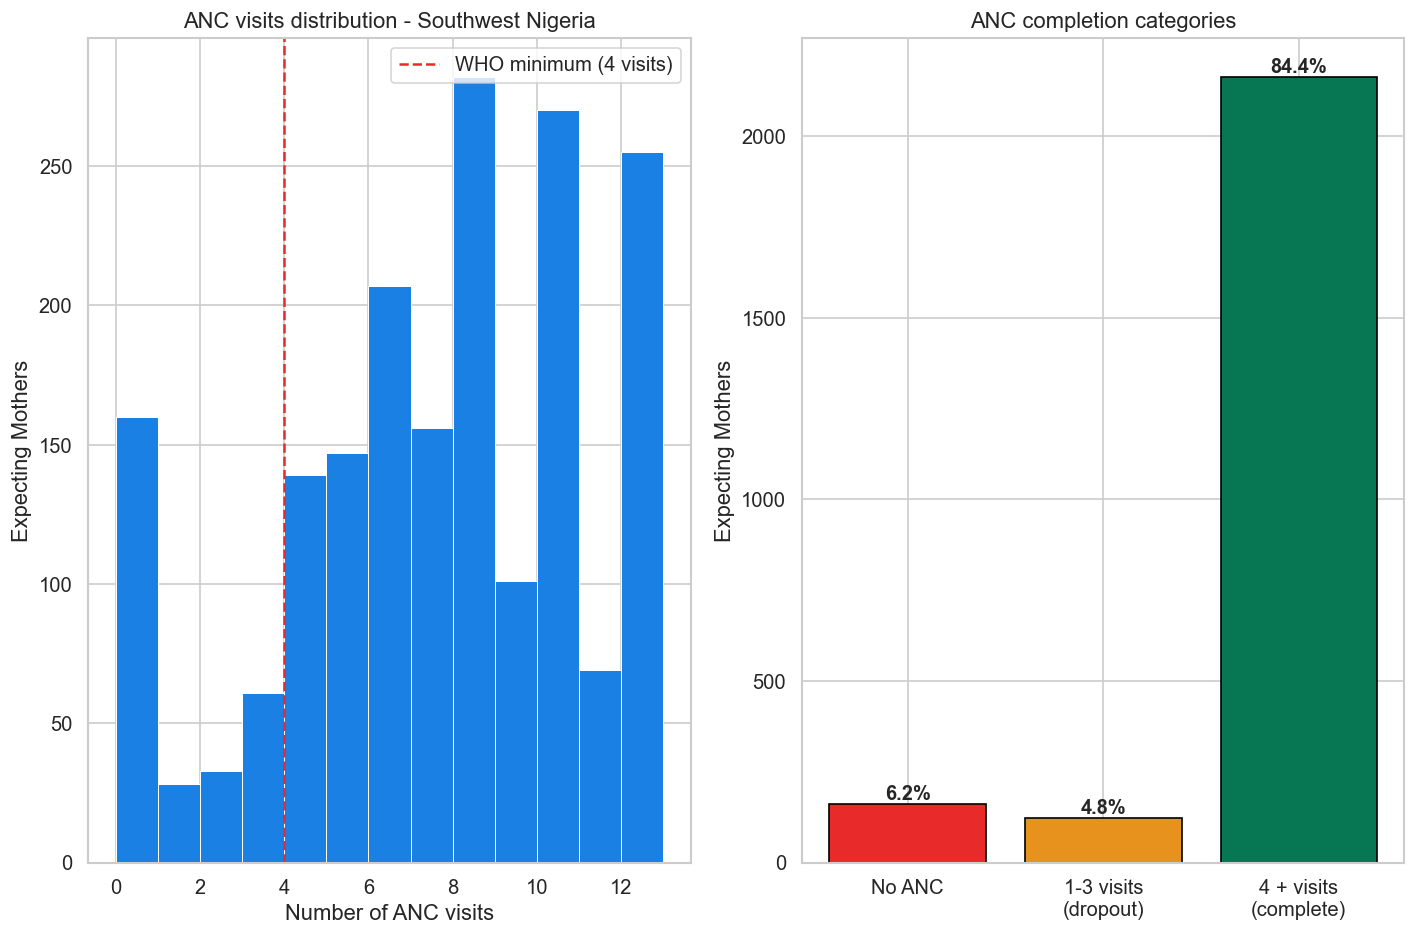

15:01:22 [INFO] Saved: ../outputs/figure1_anc_distribution.png


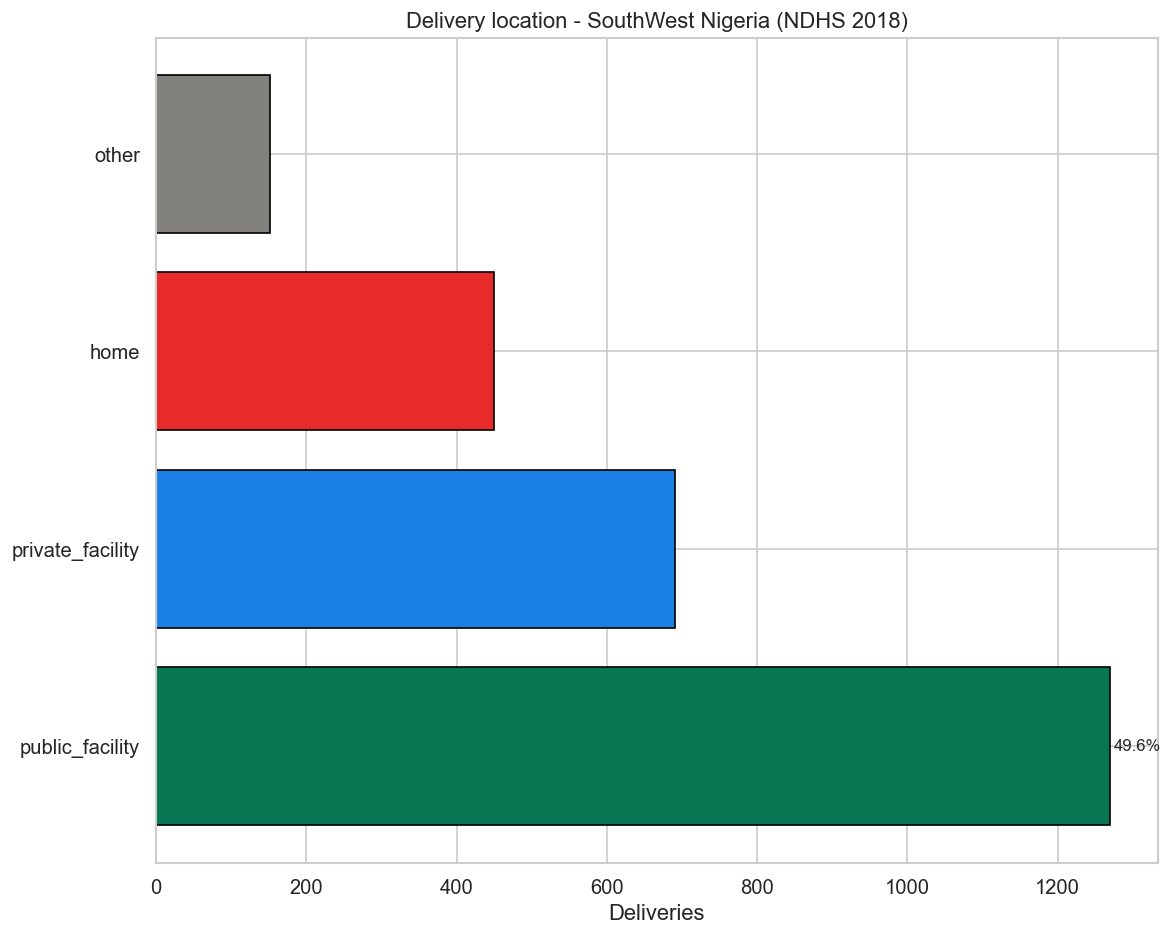

15:01:22 [INFO] Saved: ../outputs/figure2_delivery_location.png
15:01:22 [INFO] Saved: ../outputs/figure2_delivery_location.png
15:01:22 [INFO] Saved: ../outputs/figure2_delivery_location.png
15:01:22 [INFO] Saved: ../outputs/figure2_delivery_location.png


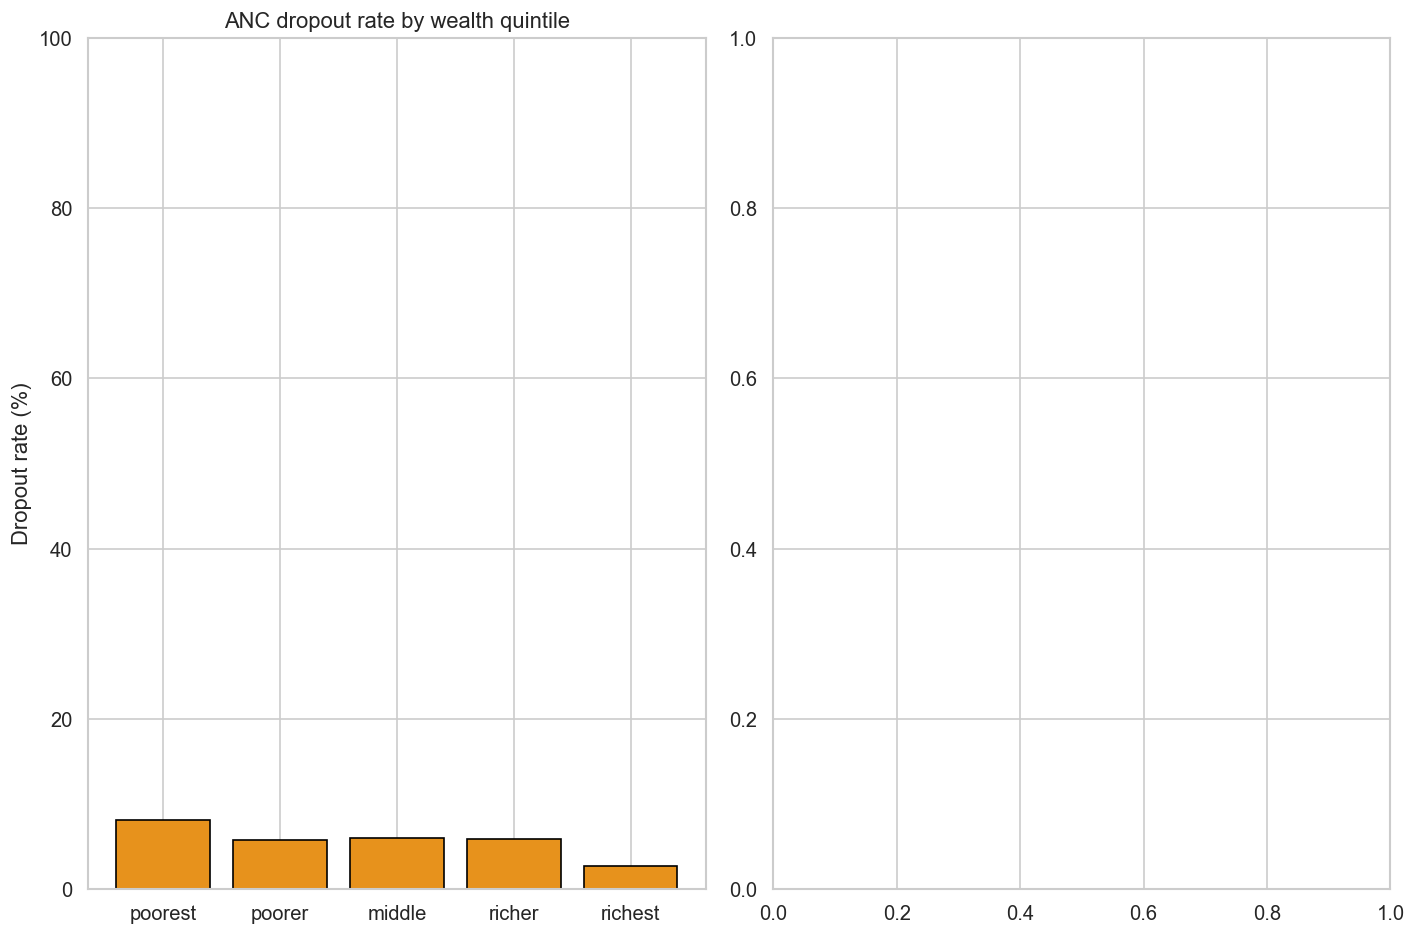

15:01:23 [INFO] Saved: ../outputs/figure3_dropout_socioeconomic.png


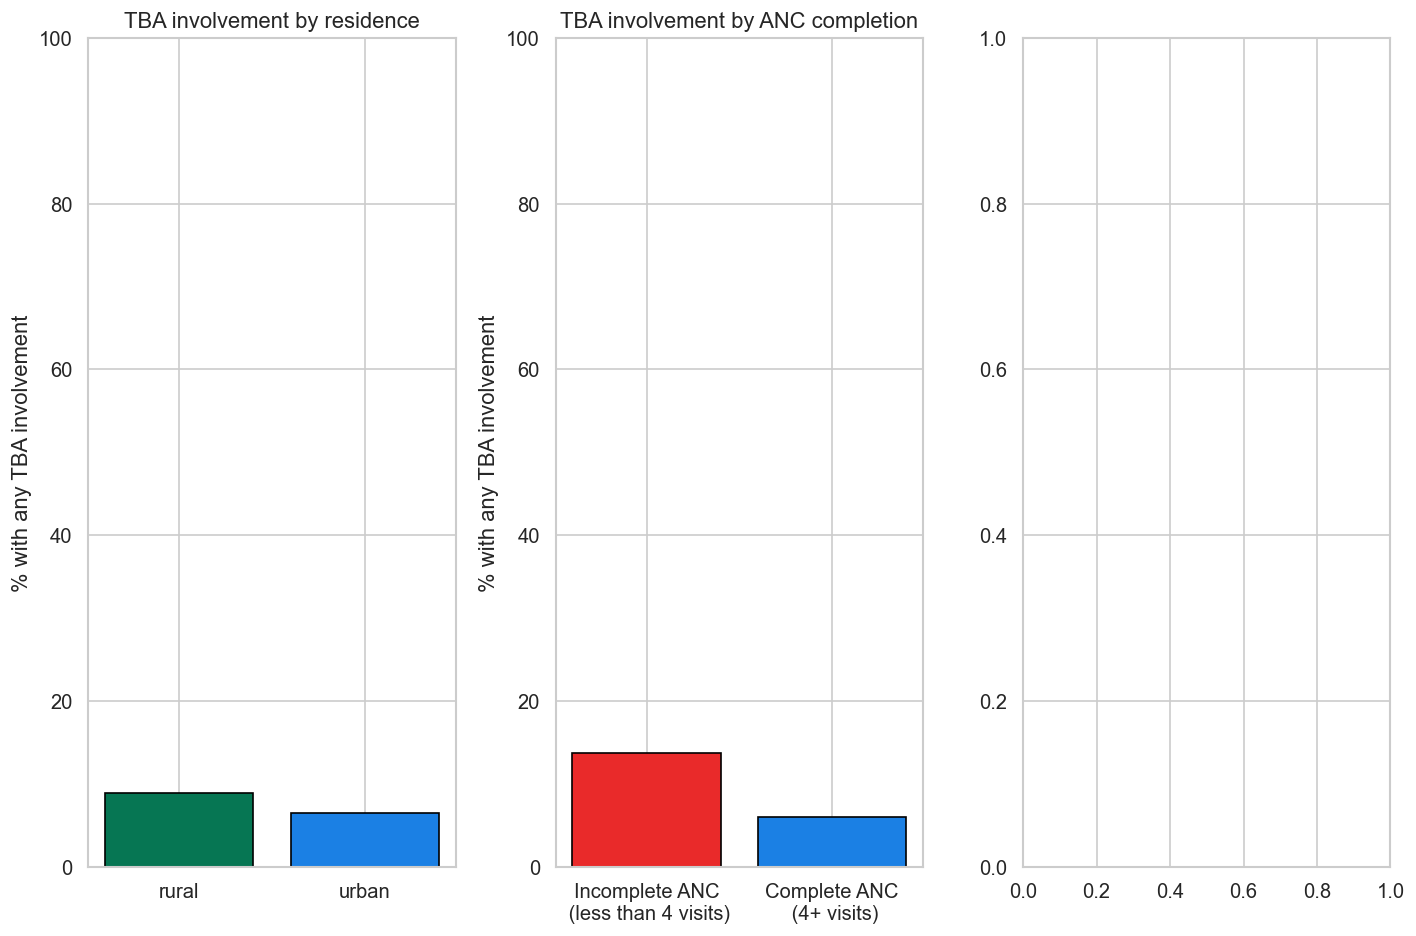

15:01:23 [INFO] Saved: ../outputs/figure4_tba_involvement.png


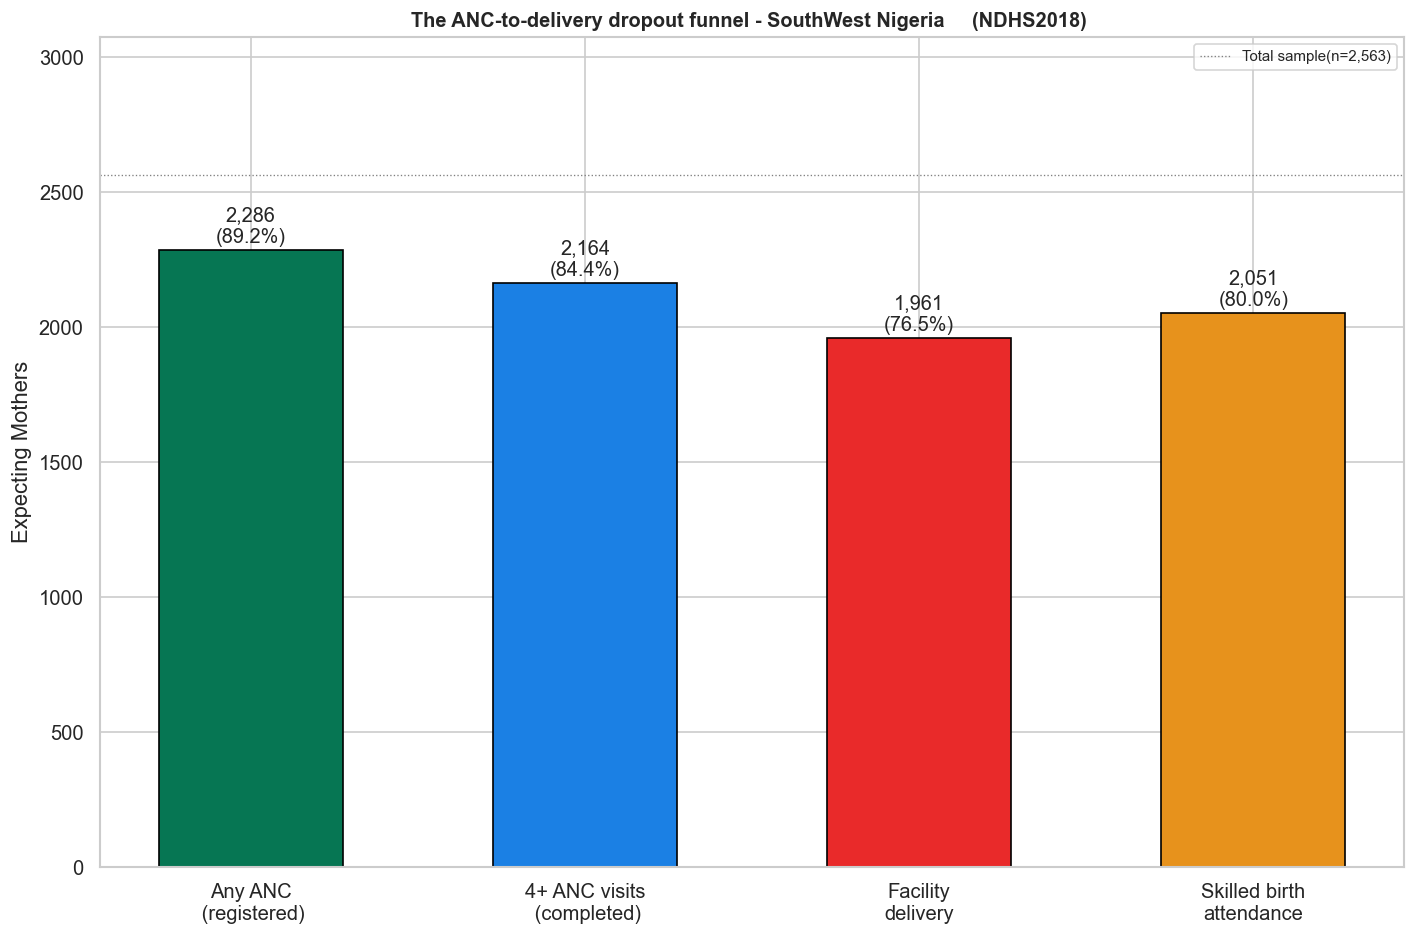

15:01:24 [INFO] Saved: ../outputs/figure5_dropout_funnel.png
15:01:24 [INFO] *** Figure 5 (dropout funnel) is the key figure for this dissertation


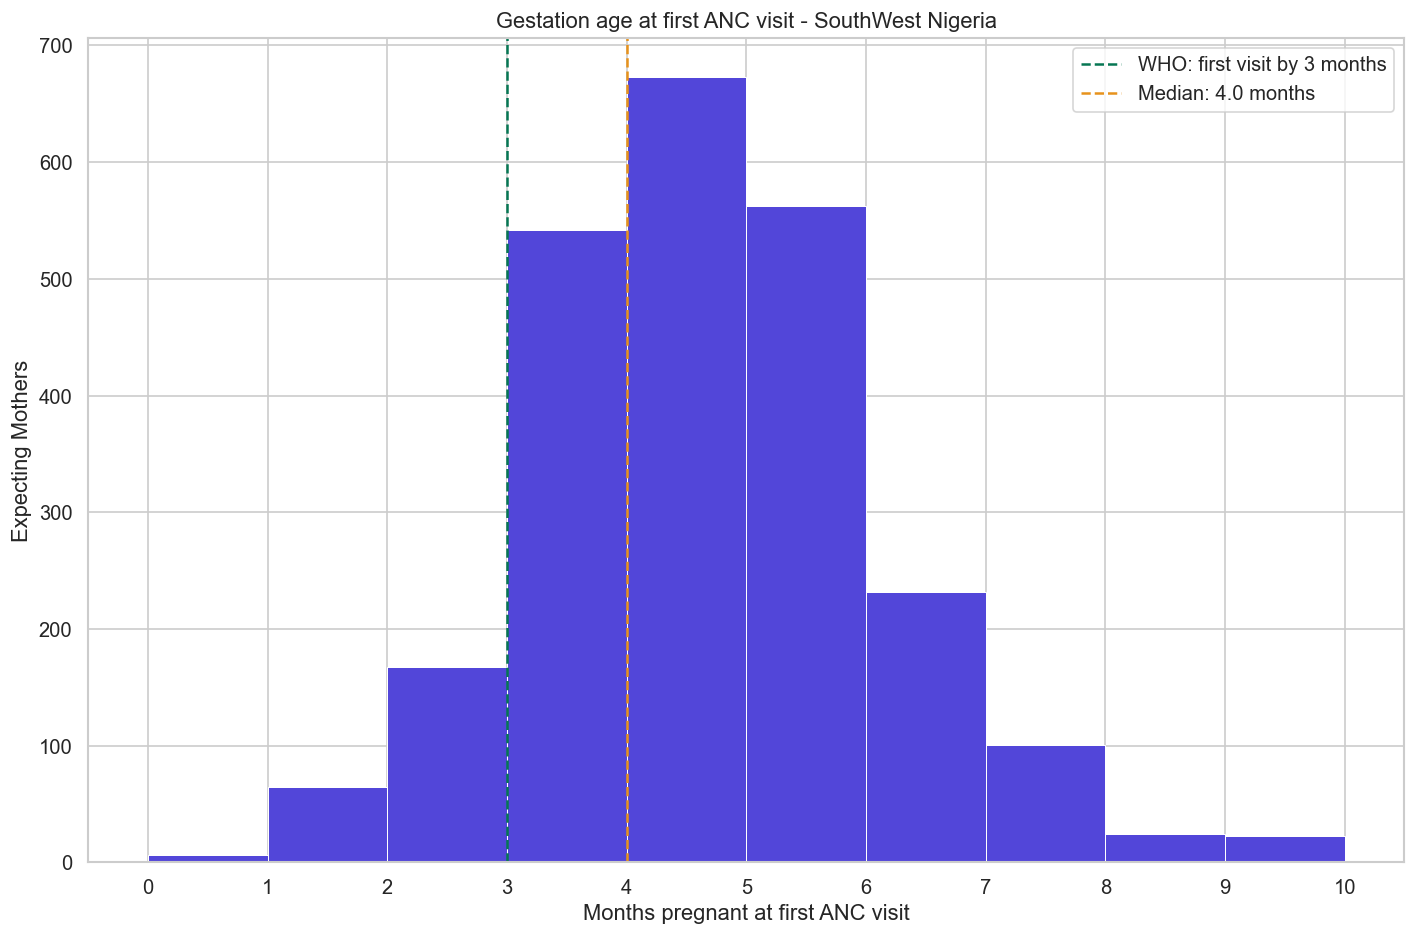

15:01:24 [INFO] Saved: ../outputs/figure6_anc_timing.png
15:01:24 [INFO] Gap report saved - ../outputs/data_completeness_gap_report.csv
15:01:24 [INFO] EDA complete. All reports and figures saved.
15:01:24 [INFO] Missing value report saved - ../outputs/missing_value_report.csv
15:01:24 [INFO] --- MamaDey AI; NDHS Pipeline COMPLETE ---



---- Data Completeness & care gap report ---
                                              Metrics  Count       %
                    Total expecting mothers in sample   2563 100.000
Started ANC but failed to complete 4 visits (dropout)    122   4.800
    Completed 4 plus ANC visits but delivered at home    272  10.600
     No formal care at all (zero ANC + home delivery)    121   4.700
                 Home deliveries with TBA involvement    106   4.100
                Any TBA involvement (ANC or delivery)    185   7.200


In [10]:
pipeline = MaternalPipeline(
    raw_path= raw_path,
    processed_dir= processed_dir,
    outputs_dir= outputs_dir,
    target_region = 6,
    target_state = None
)

df = pipeline.run()

In [12]:
# Display the shape of the dataset
print(f'Shape: {df.shape}')
df.head(3)

Shape: (2563, 34)


,cluster_id,sample_weight,residence,residence_label,age,age_group,education_level,wealth_index,wealth_label,marital_status,total_children_ever_born,living_children,anc_visits,anc_timing_months,anc_any,anc_4plus,anc_dropout,anc_late_entry,anc_provider_doc,anc_provider_nurse,anc_provider_tba,anc_blood_pressure,anc_urine_sample,anc_iron_tablets,delivery_place,delivery_location,delivery_csection,tba_any,skilled_birth,delivery_alone,child_alive,adverse_outcome,postnatal_check,data_source
36191,1162,0.475,1,urban,28,25-34,2,4,richer,1,5,3,16,5,1,1,0,1,0,1,0,0,NaN,1,12,home,0,0,0,0,1,0,1,NDHS_2018
36192,1162,0.475,1,urban,32,25-34,1,2,poorer,1,4,2,1,4,1,0,1,1,0,0,0,0,0,1,22,public_facility,0,0,1,0,1,0,1,NDHS_2018
36193,1162,0.475,1,urban,27,25-34,2,3,middle,1,3,2,9,1,1,1,0,0,0,0,0,0,4,1,22,public_facility,0,0,1,0,1,0,0,NDHS_2018


In [13]:
# Display the checklist
pipeline.checklist()

-------------------------------------------------------
COMPLETION CHECKLIST
-------------------------------------------------------
  ✓  Column audit ran successfully
  ✓  NDHS data loaded successfully
  ✓  Filtered to Southwest zone
  ✓  Filtered to recent births only
  ✓  Sample size > 500 records
  ✓  ANC visits variable present
  ✓  ANC dropout flag engineered
  ✓  Delivery location recoded
  ✓  Target variable created
  ✓  Data source flag added
  ✓  Missing value report saved
  ✓  Gap report saved
  ✗  Dropout funnel figure saved
  ✓  Cleaned dataset saved
  Some checks failed. Review output above.



### 8. Ad-hoc Access
After `pipeline.run()`, each component is independently accessible.

In [14]:
# View full column audit report
# pipeline.auditor.report

# See which variables were not found
# pipeline.auditor.missing

# Region breakdown of full raw file
# pipeline.loader.region_summary()

# Missing value report
# pipeline.cleaner.missing_report()

# Regenerate one figure without re-running everything
# pipeline.eda.plot_dropout_funnel()

# Access cleaned data for modelling
# df = pipeline.df

print('Uncomment any line above to run individually.')

Uncomment any line above to run individually.


In [26]:
class ReportGenerator_Week1_3:
    """
    Generates a structured findings report from the Week 1-3 pipeline.
    Reads results from the pipeline and eda objects already in memory.
    Saves to outputs/report_week1_3.md
    """

    def __init__(self, pipeline, outputs_dir='../outputs/'):
        self.pipeline     = pipeline
        self.outputs_dir  = outputs_dir
        self.df           = pipeline.df
        self.cleaner      = pipeline.cleaner

    def generate(self):
        metrics = self._compute_metrics()
        report  = self._build_report(metrics)
        self._print(report)
        self._save(report)
        return metrics

    def _compute_metrics(self):
        df = self.df
        n  = len(df)

        def pct(series): return round(series.mean() * 100, 1)
        def cnt(series): return int(series.sum())

        m = {
            'n_total':           n,
            'n_full_sw':         len(self.cleaner.df_full),
            'n_dropped':         self.cleaner.n_dropped_no_birth,
            'anc_4plus_pct':     pct(df['anc_4plus'])       if 'anc_4plus'   in df.columns else None,
            'anc_dropout_pct':   pct(df['anc_dropout'])     if 'anc_dropout' in df.columns else None,
            'anc_dropout_n':     cnt(df['anc_dropout'])     if 'anc_dropout' in df.columns else None,
            'no_anc_pct':        pct(df['anc_visits']==0)   if 'anc_visits'  in df.columns else None,
            'no_anc_n':          cnt(df['anc_visits']==0)   if 'anc_visits'  in df.columns else None,
            'home_del_pct':      round((df['delivery_location']=='home').mean()*100, 1)
                                 if 'delivery_location' in df.columns else None,
            'home_del_n':        int((df['delivery_location']=='home').sum())
                                 if 'delivery_location' in df.columns else None,
            'public_facility_pct':  round((df['delivery_location']=='public_facility').mean()*100, 1)
                                 if 'delivery_location' in df.columns else None,
            'private_facility_pct': round((df['delivery_location']=='private_facility').mean()*100, 1)
                                 if 'delivery_location' in df.columns else None,
            'tba_pct':           pct(df['tba_any'])         if 'tba_any'     in df.columns else None,
            'tba_n':             cnt(df['tba_any'])         if 'tba_any'     in df.columns else None,
            'skilled_pct':       pct(df['skilled_birth'])   if 'skilled_birth' in df.columns else None,
            'adverse_pct':       pct(df['adverse_outcome']) if 'adverse_outcome' in df.columns else None,
            'adverse_n':         cnt(df['adverse_outcome']) if 'adverse_outcome' in df.columns else None,
            # Gap: completed ANC but home delivery
            'anc_complete_home_del_pct': round(
                ((df['anc_4plus']==1) & (df['delivery_location']=='home')).mean()*100, 1
            ) if 'anc_4plus' in df.columns and 'delivery_location' in df.columns else None,
            'anc_complete_home_del_n': int(
                ((df['anc_4plus']==1) & (df['delivery_location']=='home')).sum()
            ) if 'anc_4plus' in df.columns and 'delivery_location' in df.columns else None,
        }
        return m

    def _build_report(self, m):
        report = f"""# MamaDey AI: Week 1-3 Findings Report
**Stage:** Data Acquisition, Cleaning and Exploratory Data Analysis
**Dataset:** Nigeria Demographic and Health Survey (NDHS) 2018 - Individual Recode (NGIR7BDT)
**Generated:** Week 1-3 Pipeline Output

---

## 1. What Was Done

The Nigeria Demographic and Health Survey (NDHS) 2018 Individual Recode was acquired from the
DHS Program and loaded into a structured data pipeline. Records were filtered to the South-West
geopolitical zone of Nigeria, the region encompassing Ogun State, and subsequently restricted
to women with a recent birth within five years of the survey date, as ANC and delivery variables
are only populated for this sub-population in the NDHS birth history structure. Exploratory data
analysis was conducted to characterise ANC attendance patterns, delivery locations, TBA involvement,
and the data completeness gap between antenatal engagement and facility delivery.

---

## 2. Key Findings

### Sample
- Full Southwest zone records loaded: **{m['n_full_sw']:,}**
- Dropped (no recent birth; out of scope): **{m['n_dropped']:,}**
- **Analytical sample (women with recent births): {m['n_total']:,}**

### ANC Attendance
- Completed 4+ ANC visits (WHO minimum): **{m['anc_4plus_pct']}%**
- Attended 1-3 visits then dropped out: **{m['anc_dropout_pct']}%** (n={m['anc_dropout_n']})
- No ANC contact at all: **{m['no_anc_pct']}%** (n={m['no_anc_n']})

### Delivery Location
- Public facility delivery: **{m['public_facility_pct']}%**
- Private facility delivery: **{m['private_facility_pct']}%**
- Home delivery: **{m['home_del_pct']}%** (n={m['home_del_n']})

### The Core Gap
- Completed full ANC (4+) but still delivered at home: **{m['anc_complete_home_del_pct']}%** (n={m['anc_complete_home_del_n']})
- Any TBA involvement (ANC or delivery): **{m['tba_pct']}%** (n={m['tba_n']})
- Skilled birth attendance: **{m['skilled_pct']}%**
- Adverse outcome (proxy; child not alive): **{m['adverse_pct']}%** (n={m['adverse_n']})

---

## 3. Dissertation-Ready Narrative

### 3.1 Analytical Sample Characteristics
The NDHS 2018 Southwest zone filter yielded a full sample of {m['n_full_sw']:,} women, of whom
{m['n_dropped']:,} were excluded as they had no recent birth and therefore no ANC or delivery data.
The analytical sample of {m['n_total']:,} women with recent births forms the primary observed dataset
for this study. This sample is geographically representative of the South-West geopolitical zone and
includes women from both urban and rural settings across the zone's six states, with Ogun State
forming part of this population.

### 3.2 ANC Attendance and Dropout Patterns
ANC completion rates in the Southwest analytical sample were relatively high compared to national
averages, with {m['anc_4plus_pct']}% of women completing the WHO-recommended minimum of four
antenatal visits. However, {m['anc_dropout_pct']}% of women (n={m['anc_dropout_n']}) attended
between one and three visits before disengaging from the formal care pathway, and a further
{m['no_anc_pct']}% (n={m['no_anc_n']}) had no formal antenatal care contact whatsoever. These
figures confirm that ANC dropout, while lower in the Southwest than in northern states, remains
a measurable and consequential phenomenon in the study region.

### 3.3 The ANC-to-Delivery Continuity Gap
The most significant finding of the exploratory analysis concerns the gap between ANC attendance
and facility delivery. Despite {m['anc_4plus_pct']}% of women completing the full ANC schedule,
only {m['public_facility_pct']}% delivered in a public facility and {m['private_facility_pct']}% in a
private facility, leaving {m['home_del_pct']}% of women (n={m['home_del_n']}) delivering at home.
Critically, {m['anc_complete_home_del_pct']}% of women (n={m['anc_complete_home_del_n']}) had
completed four or more ANC visits and still delivered outside a health facility. This finding
directly evidences the central argument of this dissertation: that ANC attendance data alone is
insufficient as a predictor of delivery risk, and that the continuity gap between antenatal
engagement and facility delivery represents the primary data visibility failure that the MamaDey AI
framework is designed to address. TBA involvement was recorded in {m['tba_pct']}% of cases
(n={m['tba_n']}), representing deliveries in which no clinically supervised escalation pathway
was available. Skilled birth attendance stood at {m['skilled_pct']}%, confirming that approximately
one in five women in this sample delivered without access to trained clinical oversight.

---

## 4. Limitations of This Stage

The NDHS 2018 is a cross-sectional survey and does not capture the longitudinal dynamics of
individual pregnancy progression. The adverse outcome proxy used in this study, child survival
status is an imperfect measure of maternal risk, as it does not directly record maternal
complications or deaths. The Southwest zone filter maximises geographic relevance but does not
isolate Ogun State specifically, as the state-level variable in NGIR7BDT uses a different coding
format that requires codebook verification before use. Additionally, the NDHS captures women at
home rather than tracing pregnancy journeys prospectively, meaning women who died in childbirth
and had no surviving household member to report on them may be underrepresented in the sample.

---
*Report generated by MamaDey AI pipeline (Week 1-3)*
"""
        return report

    def _print(self, report):
        print(report)

    def _save(self, report):
        path = f'{self.outputs_dir}report_week1_3.md'
        with open(path, 'w', encoding='utf-8') as f:
            f.write(report)
        print(f'\nReport saved -> {path}')


# Run 
report_gen = ReportGenerator_Week1_3(pipeline, outputs_dir=outputs_dir)
metrics_12 = report_gen.generate()

# MamaDey AI: Week 1-3 Findings Report
**Stage:** Data Acquisition, Cleaning and Exploratory Data Analysis
**Dataset:** Nigeria Demographic and Health Survey (NDHS) 2018 - Individual Recode (NGIR7BDT)
**Generated:** Week 1-3 Pipeline Output

---

## 1. What Was Done

The Nigeria Demographic and Health Survey (NDHS) 2018 Individual Recode was acquired from the
DHS Program and loaded into a structured data pipeline. Records were filtered to the South-West
geopolitical zone of Nigeria, the region encompassing Ogun State, and subsequently restricted
to women with a recent birth within five years of the survey date, as ANC and delivery variables
are only populated for this sub-population in the NDHS birth history structure. Exploratory data
analysis was conducted to characterise ANC attendance patterns, delivery locations, TBA involvement,
and the data completeness gap between antenatal engagement and facility delivery.

---

## 2. Key Findings

### Sample
- Full Southwest zone records load


### Next Steps
**Input file:** `data/processed/ndhs_southwest_clean.csv`  
**Next notebook:** `features_synthetic.ipynb`  
**Tasks:** feature engineering · synthetic data generation (ANC dropout population) · train/test split · SMOTE setup